# Task 12: Deriving SIR Phase-Space Plot

## Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## Defining helper functions for the simulation

In [2]:
def simple_sir_step_ahead(y, t, N, beta, gamma):
    S, I = y
    dsdt = -beta * I * (S / N)
    didt = beta * I * (S / N) - gamma * I
    return dsdt, didt


def simplified_sir_sim(N, sim_days, orig_infected, prob_infect, contact_with_people, inf_days):
    y0 = N-orig_infected, orig_infected
    beta = prob_infect*contact_with_people
    gamma = 1.0 / inf_days
    t = np.linspace(0, sim_days-1, sim_days)
    sim_res = odeint(simple_sir_step_ahead, y0, t, args=(N, beta, gamma))
    return sim_res

## Implementing the SIR Phase Space plot

In [3]:
def sir_phase_space_plot(N, sim_days, orig_infected, prob_infect, contact_with_people, inf_days):
    y = simplified_sir_sim(N, sim_days, orig_infected, prob_infect, contact_with_people, inf_days)
    plt.plot(y[:, 0], y[:, 1])

    # Direction fields creation process from: https://scipy-cookbook.readthedocs.io/items/LoktaVolterraTutorial.html
    # Creating a grid and computing the direction at each point
    nb_points = 20
    ymax = plt.ylim(ymin=0)[1]
    xmax = plt.xlim(xmin=0)[1]
    x = np.linspace(0, xmax, nb_points)
    y = np.linspace(0, ymax, nb_points)
    X1 , Y1  = np.meshgrid(x, y) 
    # Computing growth rate on the grid
    DX1, DY1 = simple_sir_step_ahead([X1 , Y1], 0, N, prob_infect*contact_with_people, 1.0 / inf_days)
    # Norm of the growth rate 
    M = (np.hypot(DX1, DY1))    
    # Avoiding zero division errors 
    M[ M == 0] = 1.0
    # Normalizing the arrows
    DX1 /= M      
    DY1 /= M

    plt.title('Trajectories and direction fields')
    # Drawing direction fields and using different colors to highlight growth speed
    Q = plt.quiver(X1, Y1, DX1, DY1, M, pivot='mid', cmap=plt.cm.jet)
    plt.xlabel('Susceptible')
    plt.ylabel('Infected')
    plt.grid()
    plt.xlim(0, xmax)
    plt.ylim(0, ymax)
    plt.show()

## Plotting the results

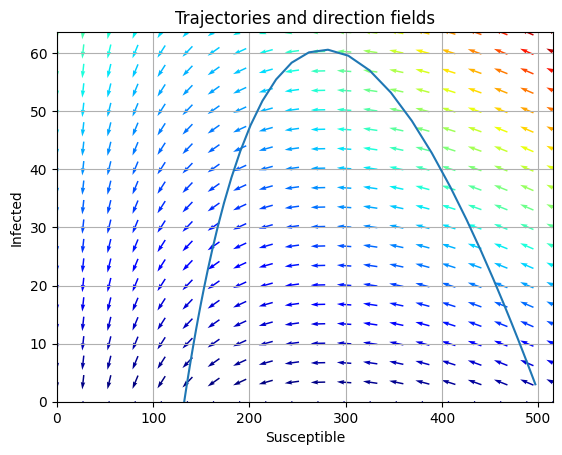

In [4]:
N, sim_days = 500, 100
orig_infected = 3
prob_infect = 0.3
contact_with_people = 2
inf_days = 3

sir_phase_space_plot(N, sim_days, orig_infected, prob_infect, contact_with_people, inf_days)